# 01 Data Exploration
Load the ALOHA dataset, inspect episodes, check camera views, and verify 14-DoF to 7-DoF isolation.

In [1]:
import sys
import os
from pathlib import Path

# Ensure repo root (containing src/) is on path
repo_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists():
        repo_root = candidate
        break
if repo_root is None:
    env_candidates = [os.getenv("VSCODE_CWD"), os.getenv("PWD")]
    for candidate in env_candidates:
        if candidate and (Path(candidate) / "src").exists():
            repo_root = Path(candidate)
            break
if repo_root is None:
    desktop = Path.home() / "Desktop"
    for candidate in desktop.rglob("NeuroCore") if desktop.exists() else []:
        if (candidate / "src").exists():
            repo_root = candidate
            break
if repo_root is None:
    for base in [Path.cwd(), Path.home()]:
        for candidate in base.rglob("data_utils.py"):
            if "NeuroCore" in str(candidate):
                repo_root = candidate.parent.parent
                break
        if repo_root is not None:
            break
if repo_root is None:
    search_bases = [Path("/home"), Path("/workspaces"), Path("/workspace")]
    for base in search_bases:
        if not base.exists():
            continue
        for root, dirs, files in os.walk(base):
            if "data_utils.py" in files and "NeuroCore" in root:
                repo_root = Path(root).parent
                break
            dirs[:] = [d for d in dirs if d not in {".git", "__pycache__", "node_modules", "proc", "sys", "dev"}]
        if repo_root is not None:
            break
if repo_root is None:
    print("Warning: Could not locate repo root containing src/; imports may fail.")
else:
    sys.path.insert(0, str(repo_root))

import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from src.data_utils import load_aloha_dataset, extract_single_arm_action

## 1. Load Dataset and Inspect Anatomy
Let's see how many episodes we have and what the features (columns) are.

In [2]:
# Load dataset
dataset = load_aloha_dataset()
train_data = dataset

# Print basic info
print("Dataset Split:", train_data)

# The episodes are structured continuously in the dataset. Let's group them by `episode_index`
# Since LeRobotDataset loads slowly when we iterate, we can query its metadata
unique_episodes = list(range(train_data.num_episodes))
print(f"Total number of episodes: {len(unique_episodes)}")
print(f"Total number of frames across all episodes: {len(train_data)}")
print("\nFeatures available in each frame:")
for feature_name, feature_type in train_data.features.items():
    print(f" - {feature_name}: {feature_type}")

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Dataset Split: LeRobotDataset({
    Repository ID: 'lerobot/aloha_sim_transfer_cube_human',
    Number of selected episodes: '50',
    Number of selected samples: '20000',
    Features: '['observation.images.top', 'observation.state', 'action', 'episode_index', 'frame_index', 'timestamp', 'next.done', 'index', 'task_index']',
})
Total number of episodes: 50
Total number of frames across all episodes: 20000

Features available in each frame:
 - observation.images.top: {'dtype': 'video', 'shape': (480, 640, 3), 'names': ['height', 'width', 'channel'], 'video_info': {'video.fps': 50.0, 'video.codec': 'av1', 'video.pix_fmt': 'yuv420p', 'video.is_depth_map': False, 'has_audio': False}}
 - observation.state: {'dtype': 'float32', 'shape': (14,), 'names': {'motors': ['left_waist', 'left_shoulder', 'left_elbow', 'left_forearm_roll', 'left_wrist_angle', 'left_wrist_rotate', 'left_gripper', 'right_waist', 'right_shoulder', 'right_elbow', 'right_forearm_roll', 'right_wrist_angle', 'right_wrist_rot

## 2. Inspect Actions and Camera Views
We'll take a look at the action tensor shapes, verify whether language instructions are present, and checkout the images from the available camera view(s).

Full action shape: 14
Full action values: tensor([-0.0138, -0.9296,  1.1796, -0.0031, -0.3298, -0.0015,  0.1637,  0.0107,
        -0.9296,  1.2026, -0.0015, -0.3191,  0.0153,  0.1900])
Single-arm (7-DoF) action shape: 7
Single-arm action values: tensor([-0.0138, -0.9296,  1.1796, -0.0031, -0.3298, -0.0015,  0.1637])
Language instruction: NONE (we will proceed with visual-only features)
Camera views available: ['observation.images.top']


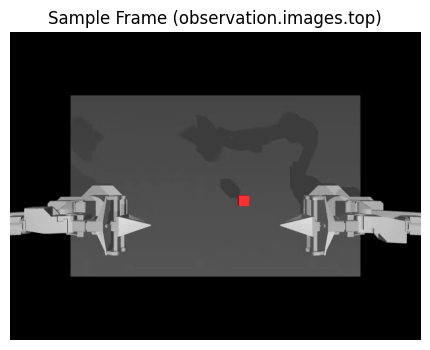

In [3]:
# Pick a random sample from episode 0
sample_idx = 0
sample = train_data[sample_idx]

# Check action tensor
full_action = sample['action']
print(f"Full action shape: {len(full_action)}")
print(f"Full action values: {full_action}")

single_arm_action = extract_single_arm_action(full_action)
print(f"Single-arm (7-DoF) action shape: {len(single_arm_action)}")
print(f"Single-arm action values: {single_arm_action}")

# Check language
if 'language_instruction' in sample:
    print(f"Language instruction: {sample['language_instruction']}")
else:
    print("Language instruction: NONE (we will proceed with visual-only features)")

# Show an image from the dataset
# Usually ALOHA has 'top', 'camera_0', etc. Let's see what image keys we have.
image_keys = [k for k in sample.keys() if 'image' in k]
print(f"Camera views available: {image_keys}")

if len(image_keys) > 0:
    view_name = image_keys[0]
    img = sample[view_name]
    if hasattr(img, 'shape') and len(img.shape) == 3:
        if isinstance(img, torch.Tensor):
            if img.shape[0] in [1, 3, 4]:
                img = img.permute(1, 2, 0).cpu().numpy()
            else:
                img = img.cpu().numpy()
        elif img.shape[0] in [1, 3, 4]:
            img = img.transpose(1, 2, 0)
    plt.figure(figsize=(6, 4))
    plt.imshow(img)
    plt.title(f"Sample Frame ({view_name})")
    plt.axis('off')
    plt.show()

## 3. Episode Length and Action Distributions
Let's see how long these demonstrations are and what the distributions of the isolated 7-DoF actions look like.

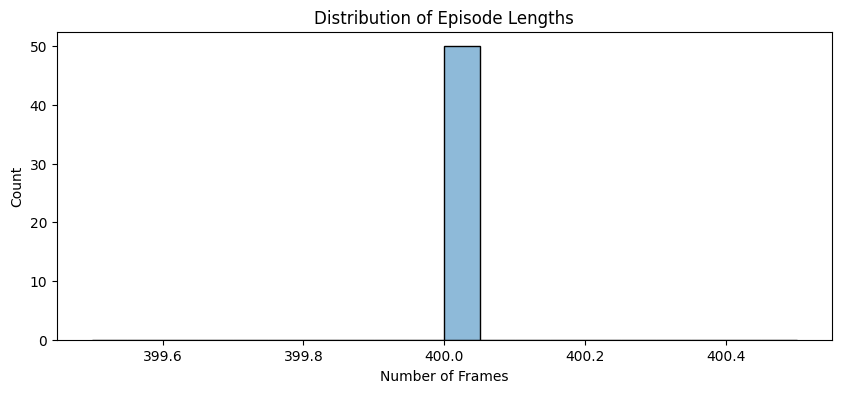

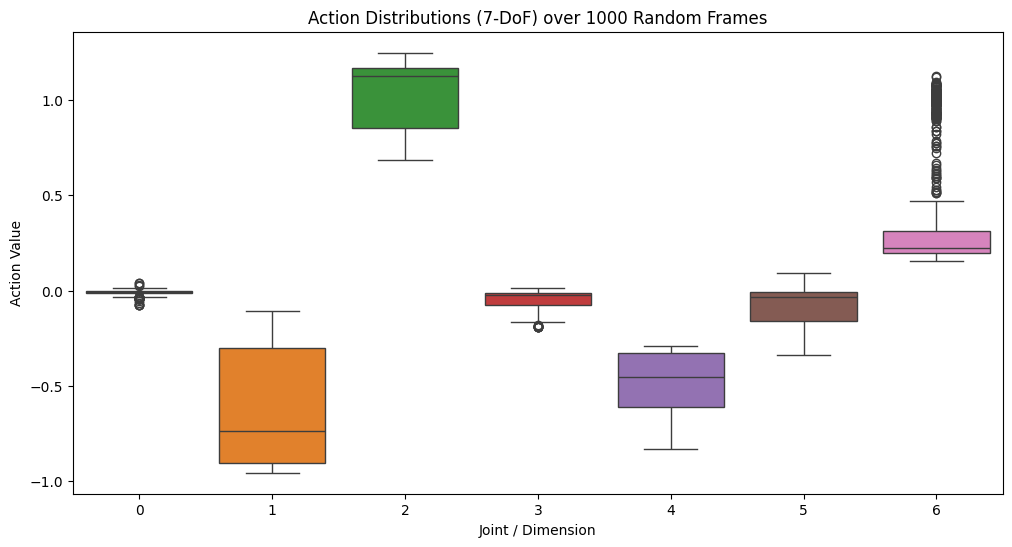

In [4]:
import numpy as np
# Compute episode lengths
episode_lengths = []
if hasattr(train_data, "episode_data_index"):
    for ep in unique_episodes:
        # Get length from dict
        length = train_data.episode_data_index['to'][ep].item() - train_data.episode_data_index['from'][ep].item()
        episode_lengths.append(length)
elif 'episode_index' in train_data.features:
    episode_indices = []
    for idx in range(len(train_data)):
        ep_idx = train_data[idx]['episode_index']
        if isinstance(ep_idx, torch.Tensor):
            ep_idx = int(ep_idx.item())
        else:
            ep_idx = int(ep_idx)
        episode_indices.append(ep_idx)
    counts = {}
    for ep_idx in episode_indices:
        counts[ep_idx] = counts.get(ep_idx, 0) + 1
    episode_lengths = [counts[ep] for ep in unique_episodes]
else:
    print("No episode index metadata found; skipping length plot.")

if episode_lengths:
    plt.figure(figsize=(10, 4))
    sns.histplot(episode_lengths, bins=20, kde=True)
    plt.title("Distribution of Episode Lengths")
    plt.xlabel("Number of Frames")
    plt.ylabel("Count")
    plt.show()

# Sample actions
sampled_actions = []
sample_indices = np.random.choice(len(train_data), min(1000, len(train_data)), replace=False)
for idx in sample_indices:
    act = extract_single_arm_action(train_data[int(idx)]['action'])
    sampled_actions.append(act)

sampled_actions = np.array(sampled_actions) # shape: (1000, 7)

plt.figure(figsize=(12, 6))
sns.boxplot(data=sampled_actions)
plt.title("Action Distributions (7-DoF) over 1000 Random Frames")
plt.xlabel("Joint / Dimension")
plt.ylabel("Action Value")
plt.show()